# 08 — Derating analysis

Created with Grok Build

| Parts | Rule |
|-------|------|
| Resistors **0805** | $P_{\mathrm{rated}}=0.125\,\mathrm{W}$ full to 70 °C; linear to 0 W at 155 °C; use ≤ 50 % of derated power |
| Capacitors **50 V** | Operate ≤ 50 % of $V_R$ → **25 V** recommended max |
| OPA365 | Supply 2.2–5.5 V; $I_Q$ power check |

Stresses are estimated from DC nodal solutions at $V_{\mathrm{in}}\in\{0,2.5,5\}\,\mathrm{V}$.
For a custom netlist, replace `estimate_stresses` with SPICE `.op`/`.tran` peaks.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


In [2]:
from opamp_design.derating import estimate_stresses, evaluate_derating, power_derating_curve

stresses = estimate_stresses(p)
for s in stresses:
    print(f"{s.name:8s}  Vpk={s.v_peak:.4g} V  I~{s.i_rms_est:.3g} A  P~{s.p_est:.3g} W  ({s.notes})")

table = evaluate_derating(p, temp_c=25.0, stresses=stresses)
display(table)

# Save
out = ROOT / "results" / "derating_table_25C.csv"
table.to_csv(out, index=False)
print("Wrote", out)

R1        Vpk=1e-06 V  I~1e-11 A  P~5.56e-16 W  (from DC nodal extremes; passband |VR| often near 0)
R2        Vpk=1e-06 V  I~1e-11 A  P~5.13e-17 W  (from DC nodal extremes; passband |VR| often near 0)
R3        Vpk=1e-06 V  I~1e-11 A  P~6.67e-18 W  (from DC nodal extremes; passband |VR| often near 0)
C1        Vpk=5 V  I~0.00104 A  P~0 W  (voltage bound from bias/swing; I~2πfCV for AC)
C2        Vpk=5 V  I~1.48e-05 A  P~0 W  (voltage bound from bias/swing; I~2πfCV for AC)
C3        Vpk=0.1 V  I~6.91e-05 A  P~0 W  (voltage bound from bias/swing; I~2πfCV for AC)
OPA365    Vpk=5 V  I~0.0046 A  P~0.023 W  (Iq typ 4.6 mA; supply within 2.2–5.5 V)


,component,package_or_rating,stress_type,stress_value,stress_unit,limit_value,derated_full_W,rated_W,margin_percent,pass,notes
0,R1,0805,power,5.555556e-16,W,0.0625,0.125,0.125,100.000000,True,from DC nodal extremes; passband |VR| often ne...
1,R1,0805,voltage,1.000000e-06,V,150.0000,0.125,0.125,99.999999,True,soft 0805 working-voltage guideline 150 V
2,R2,0805,power,5.128205e-17,W,0.0625,0.125,0.125,100.000000,True,from DC nodal extremes; passband |VR| often ne...
3,R2,0805,voltage,1.000000e-06,V,150.0000,0.125,0.125,99.999999,True,soft 0805 working-voltage guideline 150 V
4,R3,0805,power,6.666667e-18,W,0.0625,0.125,0.125,100.000000,True,from DC nodal extremes; passband |VR| often ne...
5,R3,0805,voltage,1.000000e-06,V,150.0000,0.125,0.125,99.999999,True,soft 0805 working-voltage guideline 150 V
6,C1,50 V,voltage,5.000000e+00,V,25.0000,NaN,NaN,80.000000,True,voltage bound from bias/swing; I~2πfCV for AC;...
7,C2,50 V,voltage,5.000000e+00,V,25.0000,NaN,NaN,80.000000,True,voltage bound from bias/swing; I~2πfCV for AC;...
8,C3,50 V,voltage,1.000000e-01,V,25.0000,NaN,NaN,99.600000,True,voltage bound from bias/swing; I~2πfCV for AC;...
9,OPA365,2.2–5.5 V,supply,5.000000e+00,V,5.5000,NaN,NaN,9.090909,True,Iq typ 4.6 mA; supply within 2.2–5.5 V


Wrote .\results\derating_table_25C.csv


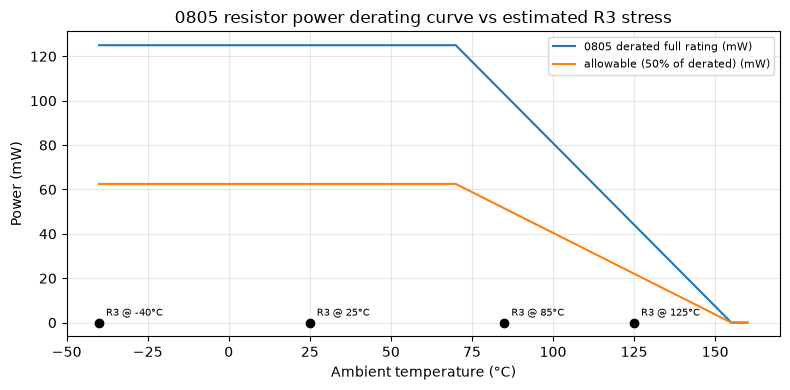

In [3]:
curve = power_derating_curve(p)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve.temp_c, curve.p_rated_curve_W * 1e3, label="0805 derated full rating (mW)")
ax.plot(curve.temp_c, curve.p_allow_W * 1e3, label="allowable (50% of derated) (mW)")
# Mark operating points
for T in [-40, 25, 85, 125]:
    row = evaluate_derating(p, temp_c=T)
    pr = row[(row.component == "R3") & (row.stress_type == "power")].stress_value.values
    if len(pr):
        ax.plot(T, pr[0] * 1e3, "ko")
        ax.annotate(f"R3 @ {T}°C", (T, max(pr[0]*1e3, 1e-6)), textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.set_xlabel("Ambient temperature (°C)")
ax.set_ylabel("Power (mW)")
ax.set_title("0805 resistor power derating curve vs estimated R3 stress")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "08_power_derating_curve.png", dpi=150)
plt.show()

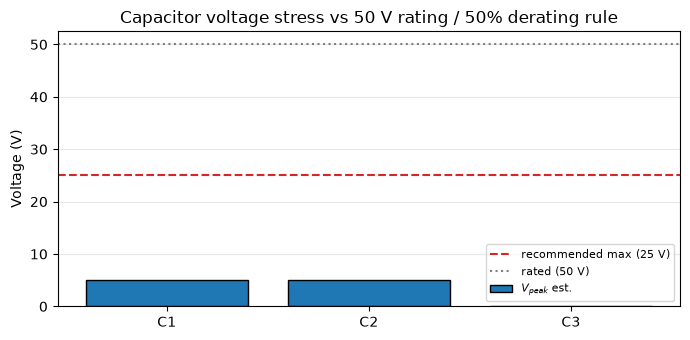

All pass? True


In [4]:
# Cap voltage margins
caps = table[(table.stress_type == "voltage") & (table.component.str.startswith("C"))]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(caps.component, caps.stress_value, label=r"$V_{peak}$ est.", color="C0", edgecolor="k")
ax.axhline(p.derating.capacitor_v_max_recommended, color="C3", ls="--",
           label=f"recommended max ({p.derating.capacitor_v_max_recommended:g} V)")
ax.axhline(p.derating.capacitor_v_rated, color="gray", ls=":", label=f"rated ({p.derating.capacitor_v_rated:g} V)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Capacitor voltage stress vs 50 V rating / 50% derating rule")
ax.legend(fontsize=8)
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "08_cap_voltage_derating.png", dpi=150)
plt.show()

print("All pass?", bool(table["pass"].all()))